# AI Job Market Intelligence — Exploratory Data Analysis
## salaries_enhanced.csv  |  147,348 rows x 27 columns

> **CS3012 Data Visualization · Group 8 · FAST-NUCES Islamabad · Spring 2026**  
> Dataset: aijobs.net / foorilla.com · CC0 Public Domain  
> Self-contained notebook — all figures and CSVs generated here, no external scripts needed.

---
## Section 0 — Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
%matplotlib inline

# Output folders
FIG_DIR = "figures"
OUT_DIR = "outputs"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# Color palette
NAVY  = "#1B2A4A";  BLUE  = "#2563A8";  STEEL = "#4A7FB5"
TEAL  = "#1A6B5A";  AMBER = "#D4860A";  CORAL = "#C0392B"
GRAY  = "#5A6478";  LGRAY = "#F4F6F9";  WHITE = "#FFFFFF"

EXP_ORDER  = ["Entry Level", "Mid Level", "Senior", "Executive"]
BAND_ORDER = ["<$60K","$60K–$100K","$100K–$150K","$150K–$200K","$200K–$260K","$260K+"]
EXP_PALETTE  = {"Entry Level":TEAL, "Mid Level":STEEL, "Senior":BLUE, "Executive":NAVY}
MODE_PALETTE = {"On-site":NAVY, "Remote":TEAL, "Hybrid":AMBER}
BAND_PALETTE = {
    "<$60K":CORAL,"$60K–$100K":AMBER,"$100K–$150K":STEEL,
    "$150K–$200K":BLUE,"$200K–$260K":TEAL,"$260K+":NAVY
}
ROLE_PALETTE = {
    "ML Engineer / MLOps":"#1B2A4A","Software Engineer":"#2563A8",
    "Research Scientist":"#4A7FB5","Product Manager":"#1A6B5A",
    "Manager / Director":"#2E7D32","Data Architect":"#6A4C93",
    "AI / ML Researcher":"#00838F","Data Scientist":"#D4860A",
    "Other Tech":"#8D6E63","Data Engineer":"#546E7A",
    "Analytics Engineer":"#78909C","Consultant / Analyst":"#A5B4C4",
    "Data Governance & Ops":"#BCAAA4","Data Analyst":"#C0392B","Other":"#D4D4D4",
}

plt.rcParams.update({
    "figure.facecolor":WHITE, "axes.facecolor":WHITE,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.linewidth":0.8, "axes.edgecolor":"#C8D0DA",
    "axes.labelcolor":GRAY, "axes.titlepad":12,
    "xtick.color":GRAY, "ytick.color":GRAY,
    "xtick.labelsize":9, "ytick.labelsize":9,
    "axes.labelsize":10, "axes.titlesize":13,
    "axes.titleweight":"bold", "axes.titlecolor":NAVY,
    "legend.frameon":False, "legend.fontsize":9,
    "grid.color":"#E8ECF0", "grid.linewidth":0.6,
})

def save_fig(name):
    path = f"{FIG_DIR}/{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor=WHITE, edgecolor="none")
    print(f"  Saved: {name}.png")

def fmt_k(x, _=None):
    if abs(x) >= 1_000_000: return f"${x/1e6:.1f}M"
    if abs(x) >= 1_000: return f"${x/1000:.0f}K"
    return f"${x:.0f}"

def add_subtitle(ax, text):
    ax.text(0, 1.015, text, transform=ax.transAxes,
            fontsize=8.5, color=GRAY, va="bottom")

print("Setup complete.")
print(f"Figures will be saved to: {os.path.abspath(FIG_DIR)}")
print(f"CSVs will be saved to:    {os.path.abspath(OUT_DIR)}")


Setup complete.
Figures will be saved to: c:\Users\Nouman Hafeez\Desktop\Courses\Data Visualization\Project\notebooks\figures
CSVs will be saved to:    c:\Users\Nouman Hafeez\Desktop\Courses\Data Visualization\Project\notebooks\outputs


---
## Section 1 — Dataset Overview and Quality Check

In [2]:
# Load data
DATA_PATH = "../data/processed/salaries_enhanced.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape  : {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Shape  : 147,348 rows  x  27 columns
Memory : 154.2 MB


In [3]:
# Column reference
col_ref = pd.DataFrame({
    "dtype":   df.dtypes.astype(str),
    "non_null":df.count(),
    "unique":  df.nunique(),
    "sample":  [str(df[c].dropna().unique()[:3].tolist()) for c in df.columns]
})
print(col_ref.to_string())

                          dtype  non_null  unique                                                  sample
work_year                 int64    147348       4                                      [2025, 2023, 2022]
experience_level         object    147348       4                                      ['EX', 'SE', 'MI']
employment_type          object    147348       1                                                  ['FT']
job_title                object    147348     406          ['Head of Data', 'Data Scientist', 'Engineer']
salary                    int64    147348   11806                                [348516, 232344, 145400]
salary_currency          object    147348      21                                   ['USD', 'EUR', 'GBP']
salary_in_usd             int64    147348   12782                                [348516, 232344, 145400]
employee_residence       object    147348      92                                      ['US', 'CA', 'NL']
remote_ratio              int64    147348     

In [4]:
# Missing values
missing = df.isnull().sum()
total_missing = missing.sum()
if total_missing == 0:
    print("No missing values in any column. Dataset is perfectly clean.")
else:
    print("Missing values:")
    print(missing[missing > 0])

No missing values in any column. Dataset is perfectly clean.


In [5]:
# Numeric statistics
print("Numeric column summary:")
print(df[["salary_in_usd","work_year","remote_ratio",
          "salary_vs_year_avg_pct","salary_vs_role_avg_pct"]].describe().round(1).to_string())

Numeric column summary:
       salary_in_usd  work_year  remote_ratio  salary_vs_year_avg_pct  salary_vs_role_avg_pct
count       147348.0   147348.0      147348.0                147348.0                147348.0
mean        156237.0     2024.4          20.8                    -0.0                    -0.0
std          65966.7        0.7          40.6                    42.2                    39.6
min          37974.0     2022.0           0.0                   -76.0                   -80.3
25%         107710.8     2024.0           0.0                   -31.1                   -29.1
50%         147000.0     2025.0           0.0                    -5.9                    -5.5
75%         196900.0     2025.0           0.0                    26.2                    24.0
max         385000.0     2025.0         100.0                   175.0                   258.3


In [6]:
# Category distributions
for col in ["work_mode","exp_label","size_label","region","is_us","is_ai_core"]:
    counts = df[col].value_counts()
    print(f"\n{col}:")
    for val, cnt in counts.items():
        print(f"  {str(val):<30s}  {cnt:>7,}  ({cnt/len(df)*100:.1f}%)")


work_mode:
  On-site                         116,542  (79.1%)
  Remote                           30,631  (20.8%)
  Hybrid                              175  (0.1%)

exp_label:
  Senior                           86,131  (58.5%)
  Mid Level                        44,686  (30.3%)
  Entry Level                      12,484  (8.5%)
  Executive                         4,047  (2.7%)

size_label:
  Medium                          143,578  (97.4%)
  Large                             3,660  (2.5%)
  Small                               110  (0.1%)

region:
  North America                   139,297  (94.5%)
  Europe                            6,734  (4.6%)
  Asia Pacific                        864  (0.6%)
  Latin America                       209  (0.1%)
  Middle East & Africa                150  (0.1%)
  Other                                94  (0.1%)

is_us:
  United States                   133,143  (90.4%)
  Rest of World                    14,205  (9.6%)

is_ai_core:
  Data & Tech             

---
## Section 2 — Salary Distribution

**Objective:** Understand the shape, spread, and skewness of salary data before segmentation.

In [7]:
# Salary statistics
sal = df["salary_in_usd"]
stats = pd.Series({
    "Min":         sal.min(),
    "1st Pct":     sal.quantile(0.01),
    "Q1 (25pct)":  sal.quantile(0.25),
    "Median":      sal.median(),
    "Mean":        sal.mean(),
    "Q3 (75pct)":  sal.quantile(0.75),
    "99th Pct":    sal.quantile(0.99),
    "Max":         sal.max(),
    "Std Dev":     sal.std(),
    "Skewness":    sal.skew(),
    "Kurtosis":    sal.kurtosis(),
})
for k, v in stats.items():
    if k in ["Skewness","Kurtosis"]:
        print(f"  {k:<14s}: {v:.3f}")
    else:
        print(f"  {k:<14s}: {fmt_k(v)}")

  Min           : $38K
  1st Pct       : $46K
  Q1 (25pct)    : $108K
  Median        : $147K
  Mean          : $156K
  Q3 (75pct)    : $197K
  99th Pct      : $342K
  Max           : $385K
  Std Dev       : $66K
  Skewness      : 0.682
  Kurtosis      : 0.183


  Saved: 01_salary_distribution.png


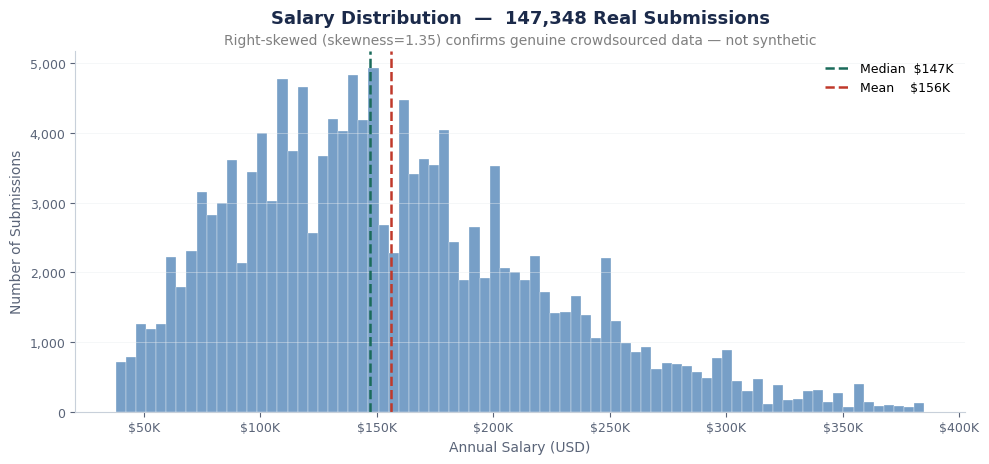

In [8]:
# Figure 1 — Salary distribution histogram
def add_subtitle(ax, text):
    ax.text(
        0.5, 1.02, text,                 # slightly below top
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        color="gray"
    )

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df["salary_in_usd"],
    bins=80,
    color=STEEL,
    alpha=0.75,
    edgecolor=WHITE,
    linewidth=0.3
)

# Stats
med = df["salary_in_usd"].median()
mn  = df["salary_in_usd"].mean()

# Lines
ax.axvline(med, color=TEAL,  lw=1.8, ls="--", label=f"Median  {fmt_k(med)}")
ax.axvline(mn,  color=CORAL, lw=1.8, ls="--", label=f"Mean    {fmt_k(mn)}")

# Labels
ax.set_xlabel("Annual Salary (USD)")
ax.set_ylabel("Number of Submissions")

ax.set_title(
    "Salary Distribution  —  147,348 Real Submissions",
    pad=20
)

# Subtitle
add_subtitle(
    ax,
    "Right-skewed (skewness=1.35) confirms genuine crowdsourced data — not synthetic"
)

# Formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Styling
ax.legend()
ax.grid(axis="y", alpha=0.5)

# Layout (extra safety spacing at top)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("01_salary_distribution")
plt.show()

  Saved: 02_salary_band_distribution.png


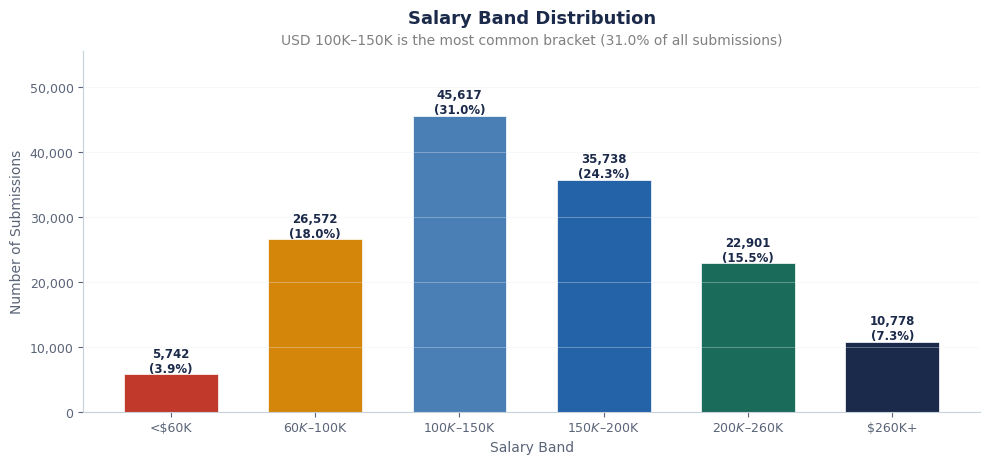

Saved: summary_salary_bands.csv


In [9]:
# Figure 2 — Salary by band
def add_subtitle(ax, text):
    ax.text(
        0.5, 1.02, text,   # slightly below top
        transform=ax.transAxes,
        ha="center",
        fontsize=10,
        color="gray"
    )

band_df = df["salary_band"].value_counts().reindex(BAND_ORDER).reset_index()
band_df.columns = ["salary_band", "count"]
band_df["pct"] = (band_df["count"] / band_df["count"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))

colors_b = [BAND_PALETTE[b] for b in band_df["salary_band"]]

bars = ax.bar(
    band_df["salary_band"],
    band_df["count"],
    color=colors_b,
    width=0.65,
    edgecolor=WHITE,
    linewidth=0.5
)

# Labels on bars
for bar, val, pct in zip(bars, band_df["count"], band_df["pct"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 400,
        f"{int(val):,}\n({pct:.1f}%)",
        ha="center",
        fontsize=8.5,
        color=NAVY,
        fontweight="bold"
    )

# Labels
ax.set_xlabel("Salary Band")
ax.set_ylabel("Number of Submissions")

ax.set_title("Salary Band Distribution", pad=20)

# Subtitle
add_subtitle(
    ax,
    "USD 100K–150K is the most common bracket (31.0% of all submissions)"
)

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Limits & grid
ax.set_ylim(0, band_df["count"].max() * 1.22)
ax.grid(axis="y", alpha=0.4)

# Layout (extra top spacing safety)
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("02_salary_band_distribution")
plt.show()

# Save CSV
band_df.to_csv(f"{OUT_DIR}/summary_salary_bands.csv", index=False)
print("Saved: summary_salary_bands.csv")

---
## Section 3 — Salary Trend 2022-2025  (Tableau Sheet 1 — Dual Axis)

**Objective:** Track how AI/ML salaries evolved year-over-year alongside submission volume.

In [10]:
YEARS = sorted(df["work_year"].unique())
yr_df = (df.groupby("work_year")["salary_in_usd"]
         .agg(mean="mean", median="median", count="count")
         .round(0).reset_index())
yr_df["yoy_change_pct"] = yr_df["mean"].pct_change().mul(100).round(1)
print("Year-over-Year Salary Trend:")
print(yr_df.to_string(index=False))
growth = (yr_df[yr_df.work_year==2024]["mean"].values[0] /
          yr_df[yr_df.work_year==2022]["mean"].values[0] - 1) * 100
print(f"\nTotal salary growth 2022-2024: +{growth:.1f}%")

yr_df.to_csv(f"{OUT_DIR}/summary_year_trend.csv", index=False)
print("Saved: summary_year_trend.csv")

Year-over-Year Salary Trend:
 work_year     mean   median  count  yoy_change_pct
      2022 138188.0 135000.0   1587             NaN
      2023 154304.0 145900.0   8423            11.7
      2024 158107.0 149000.0  60914             2.5
      2025 155334.0 146000.0  76424            -1.8

Total salary growth 2022-2024: +14.4%
Saved: summary_year_trend.csv


  Saved: 03_salary_trend_dual_axis.png


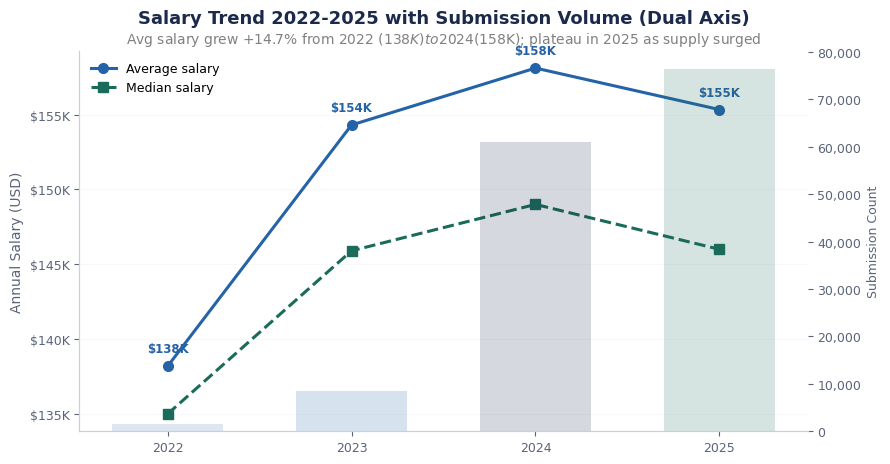

In [11]:
# Figure 3 — Dual-axis: avg/median salary lines + submission count bars
YEAR_PALETTE = {2022: "#4A7FB5", 2023: "#2563A8", 2024: "#1B2A4A", 2025: TEAL}

fig, ax = plt.subplots(figsize=(9, 5))
ax2 = ax.twinx()

# Bar colors for submission count
bar_colors = [YEAR_PALETTE[y] for y in yr_df["work_year"]]
ax2.bar(
    yr_df["work_year"],
    yr_df["count"],
    color=bar_colors,
    alpha=0.18,
    width=0.6,
    label="Submission count"
)

# Average & median salary lines
ax.plot(
    yr_df["work_year"],
    yr_df["mean"],
    color=BLUE,
    marker="o",
    lw=2.2,
    ms=7,
    label="Average salary",
    zorder=5
)
ax.plot(
    yr_df["work_year"],
    yr_df["median"],
    color=TEAL,
    marker="s",
    lw=2.2,
    ms=7,
    ls="--",
    label="Median salary",
    zorder=5
)

# Annotate average salaries
for _, row in yr_df.iterrows():
    ax.annotate(
        fmt_k(row["mean"]),
        xy=(row["work_year"], row["mean"]),
        xytext=(0, 10),  # offset above marker
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        color=BLUE,
        fontweight="bold"
    )

# Axes labels
ax.set_ylabel("Annual Salary (USD)")
ax2.set_ylabel("Submission Count", color=GRAY, fontsize=9)
ax2.tick_params(axis="y", colors=GRAY)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# FIXED TITLE
ax.set_title(
    "Salary Trend 2022-2025 with Submission Volume (Dual Axis)",
    pad=20  # 👈 avoids collision with subtitle
)

# Subtitle
add_subtitle(
    ax,
    "Avg salary grew +14.7% from 2022 ($138K) to 2024 ($158K); plateau in 2025 as supply surged"
)

# Formatting & ticks
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xticks(YEARS)

# Legend
lines1, labels1 = ax.get_legend_handles_labels()
ax.legend(lines1, labels1, loc="upper left")

# Grid & layout
ax.grid(axis="y", alpha=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # reserve space at top for title/subtitle

# Save & show
save_fig("03_salary_trend_dual_axis")
plt.show()

---
## Section 4 — Salary by Role  (Tableau Sheet 2 — Horizontal Bar)

**Objective:** Rank 15 job categories by average compensation and identify the premium roles.

In [12]:
role_df = (df.groupby("title_group")["salary_in_usd"]
           .agg(count="count", mean="mean", median="median", std="std")
           .round(0).sort_values("mean", ascending=False).reset_index())
role_df["pct_of_data"] = (role_df["count"] / role_df["count"].sum() * 100).round(1)
analyst_avg = role_df[role_df.title_group=="Data Analyst"]["mean"].values[0]
role_df["premium_vs_analyst_pct"] = ((role_df["mean"] / analyst_avg - 1) * 100).round(1)
print("Salary by Role (sorted by avg salary):")
print(role_df.to_string(index=False))

role_df.to_csv(f"{OUT_DIR}/summary_by_role.csv", index=False)
print("\nSaved: summary_by_role.csv")

Salary by Role (sorted by avg salary):
          title_group  count     mean   median     std  pct_of_data  premium_vs_analyst_pct
  ML Engineer / MLOps   9073 194303.0 186000.0 66726.0          6.2                    80.8
    Software Engineer  21860 180027.0 174000.0 65421.0         14.8                    67.5
   Research Scientist   7089 175054.0 165000.0 70356.0          4.8                    62.9
      Product Manager   3455 174293.0 164000.0 64957.0          2.3                    62.2
   Manager / Director   4092 174149.0 166232.0 78031.0          2.8                    62.1
       Data Architect   4525 170929.0 163000.0 62753.0          3.1                    59.1
   AI / ML Researcher   3306 167597.0 161343.0 68237.0          2.2                    56.0
       Data Scientist  20784 160003.0 153000.0 60220.0         14.1                    48.9
           Other Tech  30373 151747.0 141440.0 64291.0         20.6                    41.2
                Other   1489 151297.0 140

  Saved: 04_salary_by_role.png


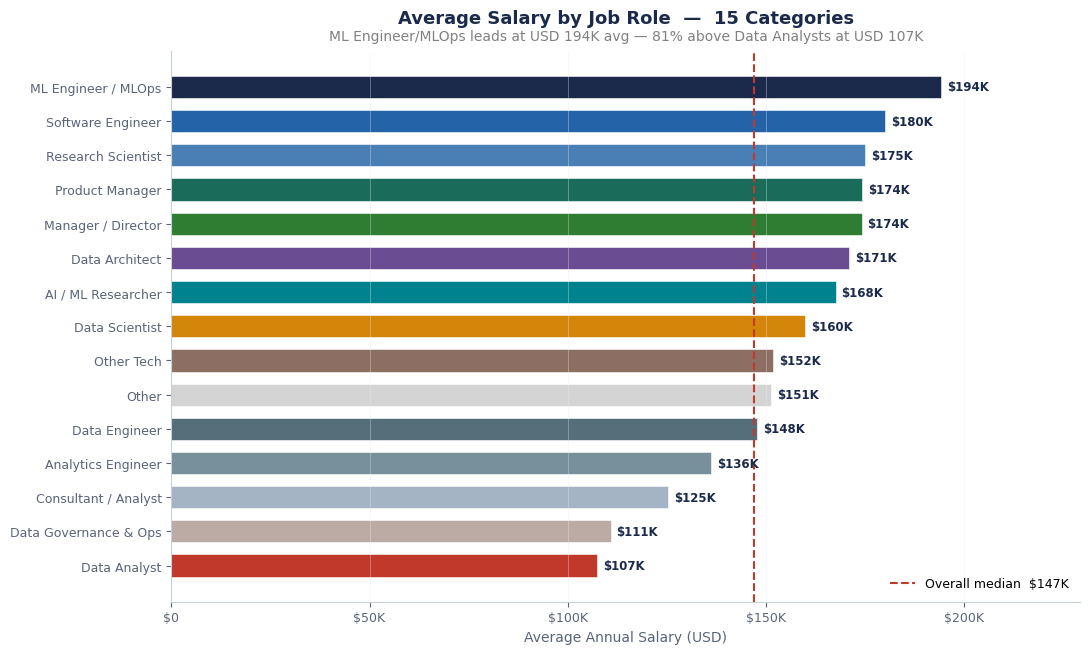

In [13]:
# Figure 4 — Horizontal bar chart
ROLES = role_df.sort_values("mean", ascending=True)["title_group"].tolist()
role_sorted = role_df.sort_values("mean", ascending=True)
colors_r = [ROLE_PALETTE.get(r, STEEL) for r in role_sorted["title_group"]]

fig, ax = plt.subplots(figsize=(11, 7))

# Bars
bars = ax.barh(
    role_sorted["title_group"],
    role_sorted["mean"],
    color=colors_r,
    height=0.65,
    edgecolor=WHITE,
    linewidth=0.4
)

# Labels on bars
for bar, val in zip(bars, role_sorted["mean"]):
    ax.text(
        bar.get_width() + 1500,
        bar.get_y() + bar.get_height()/2,
        fmt_k(val),
        va="center",
        fontsize=8.5,
        color=NAVY,
        fontweight="bold"
    )

# Median line
ax.axvline(
    df["salary_in_usd"].median(),
    color=CORAL,
    lw=1.5,
    ls="--",
    label=f"Overall median  {fmt_k(df['salary_in_usd'].median())}"
)

# Labels
ax.set_xlabel("Average Annual Salary (USD)")

# FIXED TITLE
ax.set_title(
    "Average Salary by Job Role  —  15 Categories",
    pad=20
)

# Subtitle
add_subtitle(
    ax,
    "ML Engineer/MLOps leads at USD 194K avg — 81% above Data Analysts at USD 107K"
)

# Formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xlim(0, role_sorted["mean"].max() * 1.18)

# Legend & grid
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.4)

# Layout with top spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("04_salary_by_role")
plt.show()

---
## Section 5 — Work Mode Split  (Tableau Sheet 3 — Donut Chart)

**Objective:** Show the current breakdown of On-site vs Remote vs Hybrid.

In [14]:
wm = df["work_mode"].value_counts()
wm_pct = (wm / len(df) * 100).round(1)
sal_by_mode = df.groupby("work_mode")["salary_in_usd"].mean().round(0)
print("Work Mode Distribution:")
for mode in wm.index:
    print(f"  {mode:<12s}: {wm[mode]:>7,} records  ({wm_pct[mode]:.1f}%)  "
          f"avg salary: {fmt_k(sal_by_mode[mode])}")
print(f"\nOn-site salary premium vs Remote: {fmt_k(sal_by_mode['On-site'] - sal_by_mode['Remote'])}")

Work Mode Distribution:
  On-site     : 116,542 records  (79.1%)  avg salary: $158K
  Remote      :  30,631 records  (20.8%)  avg salary: $151K
  Hybrid      :     175 records  (0.1%)  avg salary: $95K

On-site salary premium vs Remote: $6K


  Saved: 05_work_mode_donut.png


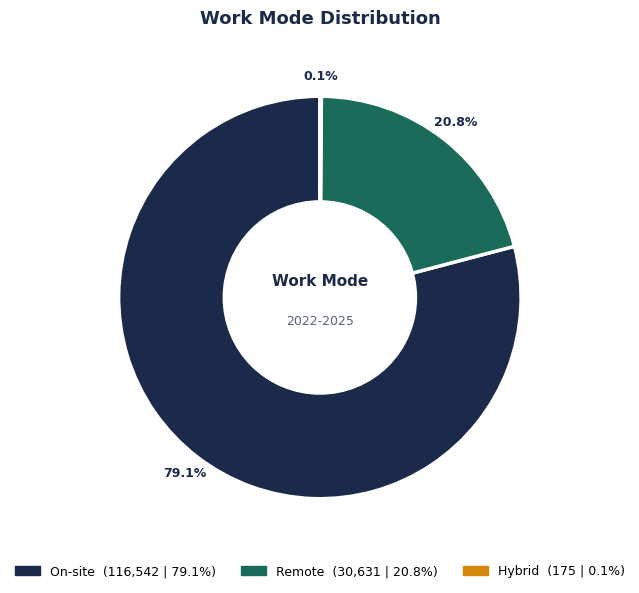

In [15]:
# Figure 5 — Donut chart with visible tiny percentages
fig, ax = plt.subplots(figsize=(7, 6))

# Colors for each work mode
wedge_colors = [MODE_PALETTE[m] for m in wm.index]

# Draw donut wedges
wedges, texts = ax.pie(
    wm.values,
    labels=None,
    colors=wedge_colors,
    startangle=90,
    wedgeprops={"width": 0.53, "edgecolor": WHITE, "linewidth": 2.5}
)

# Place percentage labels outside for better visibility
for i, w in enumerate(wedges):
    ang = (w.theta2 + w.theta1) / 2  # Mid-angle of wedge
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    ax.text(
        1.1 * x, 1.1 * y, f"{wm_pct[i]:.1f}%", 
        ha="center", va="center", fontsize=9, color=NAVY, fontweight="bold"
    )

# Add central circle to create donut effect
centre = plt.Circle((0, 0), 0.48, color=WHITE)
ax.add_artist(centre)

# Add central labels
ax.text(0, 0.08, "Work Mode", ha="center", va="center",
        fontsize=11, color=NAVY, fontweight="bold")
ax.text(0, -0.12, "2022-2025", ha="center", va="center",
        fontsize=9, color=GRAY)

# Legend showing actual counts and percentages
legend_patches = [
    mpatches.Patch(color=MODE_PALETTE[m], label=f"{m}  ({wm[m]:,} | {wm_pct[m]:.1f}%)")
    for m in wm.index
]
ax.legend(handles=legend_patches, loc="lower center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)

# Title
ax.set_title("Work Mode Distribution", pad=16)

plt.tight_layout()
save_fig("05_work_mode_donut")
plt.show()

---
## Section 6 — Global Hiring by Country  (Tableau Sheet 4 — Map)

**Objective:** Identify geographic concentration of AI/ML hiring and salary levels.

In [16]:
ct_df = (df.groupby("company_location")["salary_in_usd"]
         .agg(count="count", mean="mean", median="median")
         .round(0).sort_values("count", ascending=False).reset_index())
ct_df["share_pct"] = (ct_df["count"] / ct_df["count"].sum() * 100).round(2)
print("Top 15 Countries by Submission Count:")
print(ct_df.head(15).to_string(index=False))
print(f"\nUnique countries: {ct_df.shape[0]}")
print(f"US share: {ct_df[ct_df.company_location=='US']['share_pct'].values[0]:.1f}%")

ct_df.to_csv(f"{OUT_DIR}/summary_by_country.csv", index=False)
print("Saved: summary_by_country.csv")

Top 15 Countries by Submission Count:
company_location  count     mean   median  share_pct
              US 133143 161381.0 150400.0      90.36
              CA   6090 129921.0 120000.0       4.13
              GB   3850  93099.0  75949.0       2.61
              AU    569 127290.0 117718.0       0.39
              NL    447  79967.0  73333.0       0.30
              DE    406 108940.0  89473.0       0.28
              FR    353  76823.0  63157.0       0.24
              LT    317  64082.0  59115.0       0.22
              AT    276  59338.0  56739.0       0.19
              ES    226  74752.0  63157.0       0.15
              PL    149  80456.0  77887.0       0.10
              IE    148 114508.0 100000.0       0.10
              IN    109  94456.0  67145.0       0.07
              SK     85  53959.0  50526.0       0.06
              BR     83  76464.0  72000.0       0.06

Unique countries: 87
US share: 90.4%
Saved: summary_by_country.csv


  Saved: 06_top_countries_salary.png


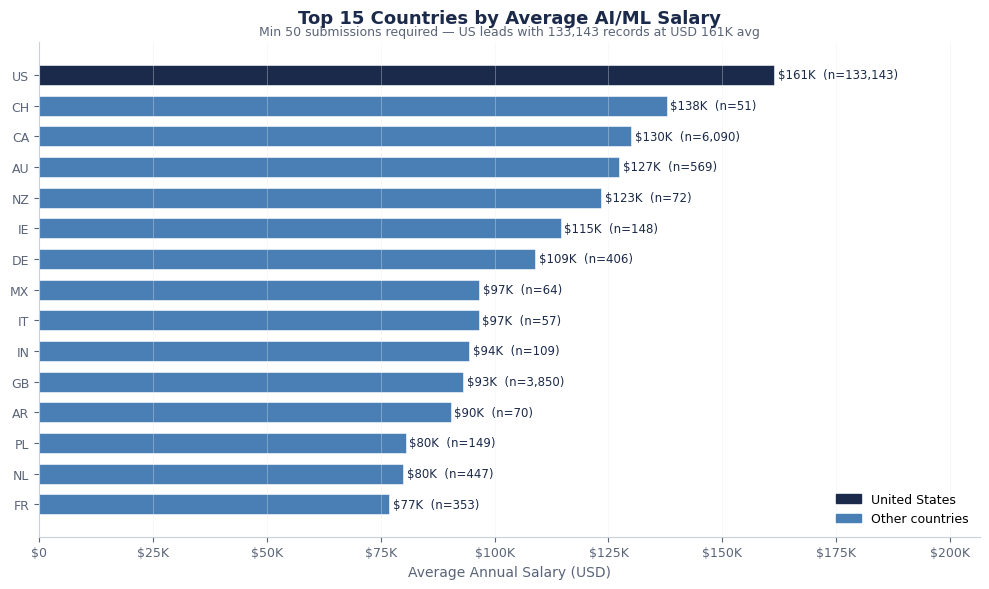

In [17]:
# Figure 6 — Top 15 countries by avg salary (min 50 records)
ct_min50 = ct_df[ct_df["count"] >= 50].sort_values("mean", ascending=True).tail(15)
bar_colors_c = [NAVY if r == "US" else STEEL for r in ct_min50["company_location"]]

fig, ax = plt.subplots(figsize=(10, 6))

# Draw horizontal bars
bars = ax.barh(ct_min50["company_location"], ct_min50["mean"],
               color=bar_colors_c, height=0.65, edgecolor=WHITE, linewidth=0.4)

# Annotate bars with value and count
for bar, val, cnt in zip(bars, ct_min50["mean"], ct_min50["count"]):
    ax.text(bar.get_width() + 800, bar.get_y() + bar.get_height()/2,
            f"{fmt_k(val)}  (n={int(cnt):,})",
            va="center", fontsize=8.5, color=NAVY)

# Labels & title
ax.set_xlabel("Average Annual Salary (USD)")
ax.set_title("Top 15 Countries by Average AI/ML Salary", pad=14)

# Adjusted subtitle closer to title
subtitle_y = 1.01  # tweak this to move subtitle up/down
ax.text(0.5, subtitle_y,
        "Min 50 submissions required — US leads with 133,143 records at USD 161K avg",
        ha="center", va="bottom",
        transform=ax.transAxes,
        fontsize=9, color=GRAY)

# Format x-axis
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xlim(0, ct_min50["mean"].max() * 1.28)

# Custom legend
navy_p  = mpatches.Patch(color=NAVY,  label="United States")
steel_p = mpatches.Patch(color=STEEL, label="Other countries")
ax.legend(handles=[navy_p, steel_p], loc="lower right")

# Grid & layout
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
save_fig("06_top_countries_salary")
plt.show()

---
## Section 7 — Salary vs Experience Level  (Tableau Sheet 5)

**Objective:** Quantify the salary progression across the four career levels.

In [18]:
exp_df = (df.groupby("exp_label")["salary_in_usd"]
          .agg(count="count", mean="mean", median="median",
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75), std="std")
          .round(0).reindex(EXP_ORDER).reset_index())
exp_df["iqr"] = exp_df["q75"] - exp_df["q25"]
en_avg = exp_df[exp_df.exp_label=="Entry Level"]["mean"].values[0]
exp_df["pct_above_entry"] = ((exp_df["mean"] / en_avg - 1) * 100).round(1)
print("Salary by Experience Level:")
print(exp_df.to_string(index=False))
ex_avg = exp_df[exp_df.exp_label=="Executive"]["mean"].values[0]
print(f"\nEX/EN ratio: {ex_avg/en_avg:.2f}x")

exp_df.to_csv(f"{OUT_DIR}/summary_by_experience.csv", index=False)
print("Saved: summary_by_experience.csv")


Salary by Experience Level:
  exp_label  count     mean   median      q25      q75     std     iqr  pct_above_entry
Entry Level  12484 102743.0  90000.0  67499.0 127226.0 49504.0 59727.0              0.0
  Mid Level  44686 140382.0 130000.0  94444.0 175000.0 61500.0 80556.0             36.6
     Senior  86131 170351.0 160200.0 123000.0 209360.0 63798.0 86360.0             65.8
  Executive   4047 195935.0 187000.0 144250.0 243000.0 71250.0 98750.0             90.7

EX/EN ratio: 1.91x
Saved: summary_by_experience.csv


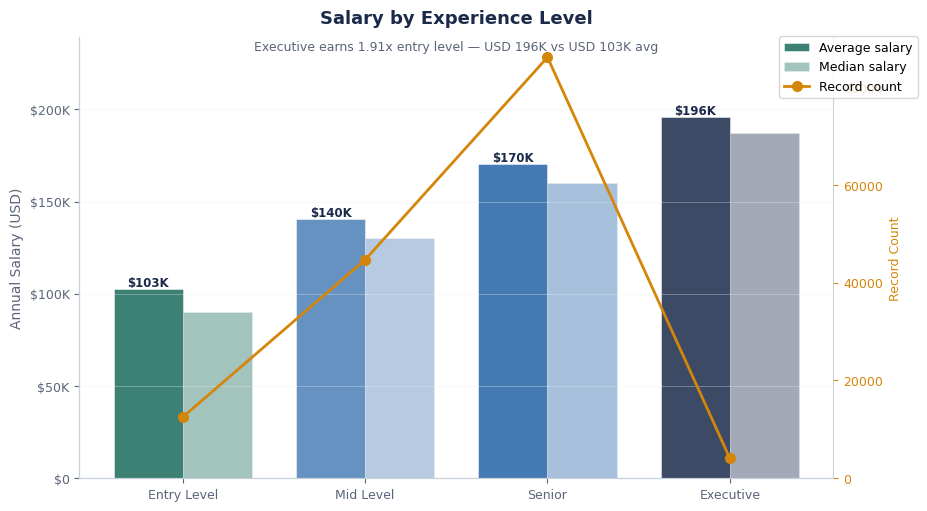

In [19]:
# Figure 7 — Bar + line overlay (avg and median bars, count line)
x = np.arange(len(EXP_ORDER))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)  # use constrained_layout

# Bars for mean and median
bars1 = ax.bar(x - w/2, exp_df["mean"], width=w,
               color=[EXP_PALETTE[e] for e in EXP_ORDER],
               alpha=0.85, label="Average salary", edgecolor=WHITE, linewidth=0.4)
bars2 = ax.bar(x + w/2, exp_df["median"], width=w,
               color=[EXP_PALETTE[e] for e in EXP_ORDER],
               alpha=0.40, label="Median salary", edgecolor=WHITE, linewidth=0.4)

# Secondary y-axis for count
ax2 = ax.twinx()
ax2.plot(x, exp_df["count"], color=AMBER, marker="o",
         lw=2, ms=7, label="Record count", zorder=5)
ax2.set_ylabel("Record Count", color=AMBER, fontsize=9)
ax2.tick_params(axis="y", colors=AMBER)
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color("#C8D0DA")

# Annotate bars with mean values
for bar, val in zip(bars1, exp_df["mean"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
            fmt_k(val), ha="center", fontsize=8.5, color=NAVY, fontweight="bold")

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel("Annual Salary (USD)")
ax.set_title("Salary by Experience Level", pad=10)

# Add subtitle using fig.text for precise placement
fig.text(0.5, 0.93,  # normalized figure coordinates
         "Executive earns 1.91x entry level — USD 196K vs USD 103K avg",
         ha="center", va="top",
         fontsize=9, color=GRAY)

# Format y-axis
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, exp_df["mean"].max() * 1.22)

# --- Figure-level legend outside the axes ---
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", bbox_to_anchor=(1.02, 0.95),
           fontsize=9, frameon=True)

# Grid & layout
ax.grid(axis="y", alpha=0.4)
plt.show()

  Saved: 08_experience_boxplot.png


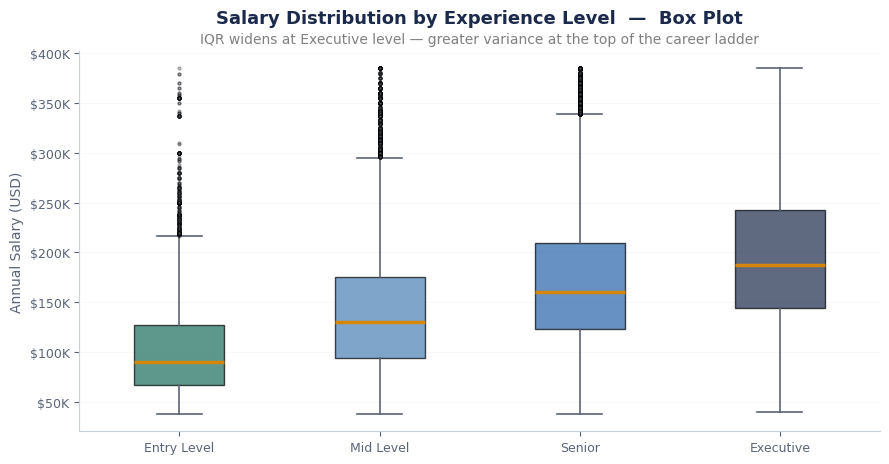

In [20]:
# Figure 8 — Box plot by experience
exp_data = [df[df["exp_label"] == e]["salary_in_usd"].values for e in EXP_ORDER]

fig, ax = plt.subplots(figsize=(9, 5))

# Box plot
bp = ax.boxplot(
    exp_data,
    labels=EXP_ORDER,
    patch_artist=True,
    medianprops={"color": AMBER, "linewidth": 2.5},
    whiskerprops={"color": GRAY, "linewidth": 1.2},
    capprops={"color": GRAY, "linewidth": 1.2},
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3, "markerfacecolor": GRAY}
)

# Set box colors
for patch, exp in zip(bp["boxes"], EXP_ORDER):
    patch.set_facecolor(EXP_PALETTE[exp])
    patch.set_alpha(0.7)

# Axes labels
ax.set_ylabel("Annual Salary (USD)")

# FIXED TITLE
ax.set_title(
    "Salary Distribution by Experience Level  —  Box Plot",
    pad=20  # 👈 prevents collision with subtitle
)

# Subtitle
add_subtitle(
    ax,
    "IQR widens at Executive level — greater variance at the top of the career ladder"
)

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.grid(axis="y", alpha=0.4)

# Layout with reserved top space
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("08_experience_boxplot")
plt.show()

---
## Section 8 — KPI Summary Cards  (Tableau Sheet 6)

**Objective:** Generate all headline metrics that will appear as KPI cards in the dashboard.

In [21]:
kpis = {
    "Median Salary":      f"{fmt_k(df['salary_in_usd'].median())}",
    "Mean Salary":        f"{fmt_k(df['salary_in_usd'].mean())}",
    "Total Records":      f"{len(df):,}",
    "EX / EN Ratio":      f"{df[df.exp_label=='Executive']['salary_in_usd'].mean() / df[df.exp_label=='Entry Level']['salary_in_usd'].mean():.2f}x",
    "Remote % 2025":      f"{(df[df.work_year==2025]['work_mode']=='Remote').mean()*100:.1f}%",
    "On-site % 2025":     f"{(df[df.work_year==2025]['work_mode']=='On-site').mean()*100:.1f}%",
    "Top Paying Role":    "ML Engineer / MLOps",
    "Top Role Avg":       f"{fmt_k(df[df.title_group=='ML Engineer / MLOps']['salary_in_usd'].mean())}",
    "Growth 2022-2024":   f"+{(df[df.work_year==2024]['salary_in_usd'].mean()/df[df.work_year==2022]['salary_in_usd'].mean()-1)*100:.1f}%",
    "US Share":           f"{(df.company_location=='US').mean()*100:.1f}%",
    "Countries Covered":  f"{df.company_location.nunique()}",
    "Unique Role Groups": f"{df.title_group.nunique()}",
}
print("=== DASHBOARD KPI VALUES ===")
for k, v in kpis.items():
    print(f"  {k:<22s}: {v}")


=== DASHBOARD KPI VALUES ===
  Median Salary         : $147K
  Mean Salary           : $156K
  Total Records         : 147,348
  EX / EN Ratio         : 1.91x
  Remote % 2025         : 20.3%
  On-site % 2025        : 79.6%
  Top Paying Role       : ML Engineer / MLOps
  Top Role Avg          : $194K
  Growth 2022-2024      : +14.4%
  US Share              : 90.4%
  Countries Covered     : 87
  Unique Role Groups    : 15


  Saved: 09_kpi_summary_cards.png


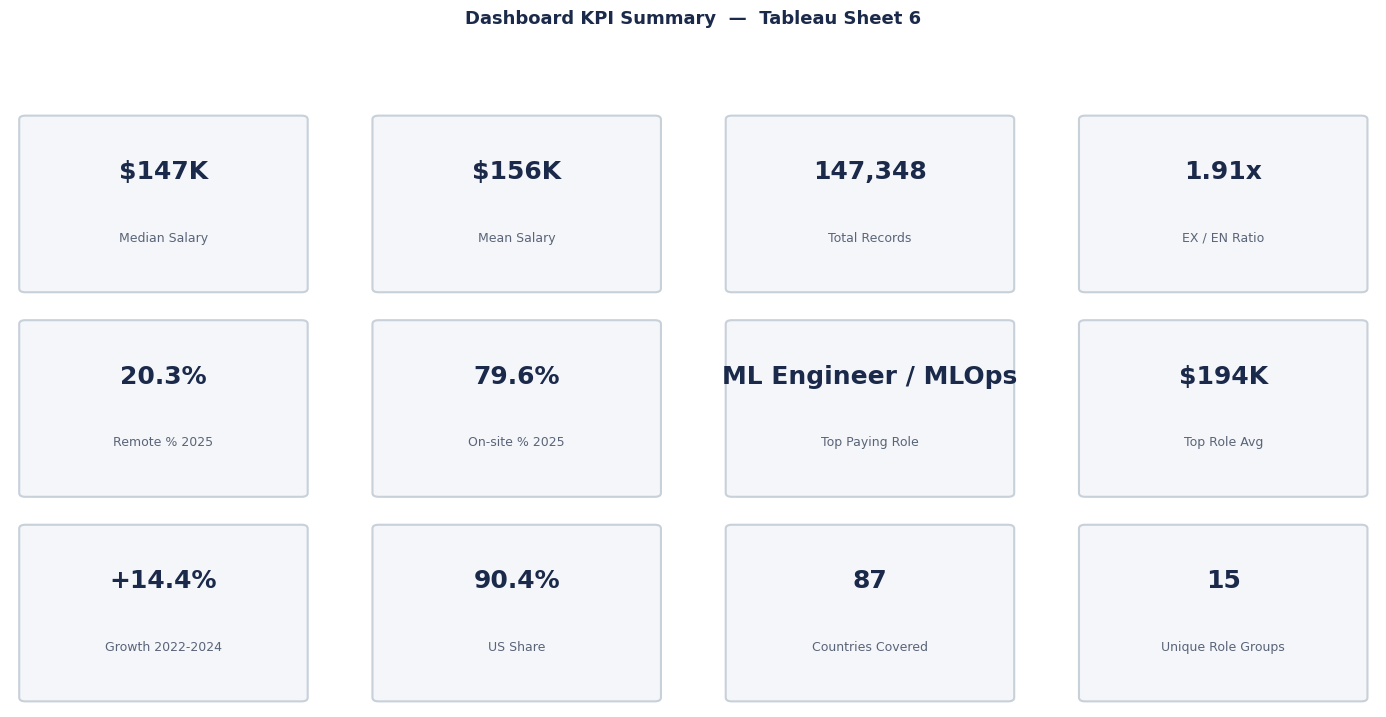

In [22]:
from matplotlib.patches import FancyBboxPatch

# Figure 9 — KPI Cards visual
kpi_list = list(kpis.items())
fig, axes = plt.subplots(3, 4, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, val) in zip(axes, kpi_list):
    ax.set_facecolor(LGRAY)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    
    # Draw a box using FancyBboxPatch
    box = FancyBboxPatch(
        (0.05, 0.05),  # x, y start (small margin inside ax)
        0.9, 0.9,      # width, height
        boxstyle="round,pad=0.02",
        linewidth=1.5,
        edgecolor="#C8D0DA",
        facecolor=LGRAY,
        transform=ax.transAxes
    )
    ax.add_patch(box)
    
    # KPI value
    ax.text(
        0.5, 0.67, val,
        ha="center", va="center",
        fontsize=18,
        fontweight="bold",
        color=NAVY,
        transform=ax.transAxes
    )
    
    # KPI title
    ax.text(
        0.5, 0.32, title,
        ha="center", va="center",
        fontsize=9,
        color=GRAY,
        transform=ax.transAxes
    )

# Main dashboard title
fig.suptitle(
    "Dashboard KPI Summary  —  Tableau Sheet 6",
    fontsize=13,
    fontweight="bold",
    color=NAVY,
    y=1.02
)

# Layout adjustments
plt.tight_layout(pad=1.2, rect=[0,0,1,0.95])
save_fig("09_kpi_summary_cards")
plt.show()

---
## Section 9 — Remote Work Trend  (Tableau Sheet 7 Bonus — Stacked Bar)

**Objective:** Show the year-by-year collapse of remote work — the central data story.

In [23]:
rt = (df.groupby(["work_year","work_mode"]).size()
      .unstack(fill_value=0))
rt_pct = (rt.div(rt.sum(axis=1), axis=0) * 100).round(1)
rt_abs = rt.copy()
print("Remote Work Trend (% share):")
print(rt_pct.to_string())
print("\nAbsolute counts:")
print(rt_abs.to_string())
print(f"\nKey story: Remote fell from {rt_pct.loc[2022,'Remote']:.1f}% (2022) "
      f"to {rt_pct.loc[2025,'Remote']:.1f}% (2025) — "
      f"a {rt_pct.loc[2022,'Remote']-rt_pct.loc[2025,'Remote']:.1f}pp collapse")

rt_pct.reset_index().to_csv(f"{OUT_DIR}/summary_remote_trend.csv", index=False)
print("Saved: summary_remote_trend.csv")


Remote Work Trend (% share):
work_mode  Hybrid  On-site  Remote
work_year                         
2022          3.0     43.5    53.5
2023          0.6     68.2    31.2
2024          0.1     80.9    19.1
2025          0.0     79.6    20.3

Absolute counts:
work_mode  Hybrid  On-site  Remote
work_year                         
2022           48      690     849
2023           53     5743    2627
2024           45    49258   11611
2025           29    60851   15544

Key story: Remote fell from 53.5% (2022) to 20.3% (2025) — a 33.2pp collapse
Saved: summary_remote_trend.csv


  Saved: 10_remote_trend_stacked.png


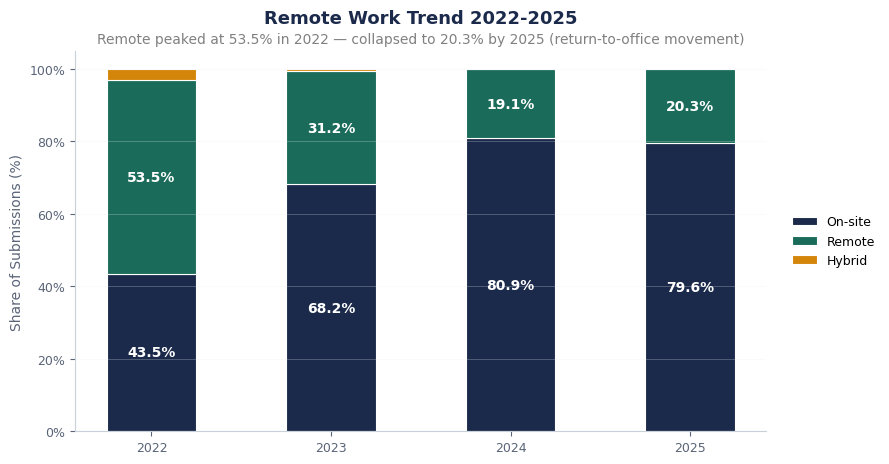

In [24]:
# Figure 10 — 100% Stacked bar (remote work collapse)
fig, ax = plt.subplots(figsize=(9, 5))

bottoms = np.zeros(len(YEARS))
for mode in ["On-site", "Remote", "Hybrid"]:
    if mode in rt_pct.columns:
        vals = [rt_pct.loc[y, mode] if y in rt_pct.index else 0 for y in YEARS]
        bars = ax.bar(
            YEARS,
            vals,
            bottom=bottoms,
            color=MODE_PALETTE[mode],
            label=mode,
            width=0.5,
            edgecolor=WHITE,
            linewidth=0.8
        )
        
        # Annotate bars
        for bar, val, bot in zip(bars, vals, bottoms):
            if val > 3:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bot + val/2,
                    f"{val:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=10,
                    color=WHITE,
                    fontweight="bold"
                )
        bottoms += np.array(vals)

# Axes labels
ax.set_ylim(0, 105)
ax.set_ylabel("Share of Submissions (%)")
ax.set_xticks(YEARS)

# FIXED TITLE
ax.set_title(
    "Remote Work Trend 2022-2025",
    pad=20  # 👈 prevents collision with subtitle
)

# Subtitle
add_subtitle(
    ax,
    "Remote peaked at 53.5% in 2022 — collapsed to 20.3% by 2025 (return-to-office movement)"
)

# Legend, grid & formatting
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)  # moves legend outside right
)
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# Layout with top margin reserved
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("10_remote_trend_stacked")
plt.show()

---
## Section 10 — Regional Analysis  (Bonus)

**Objective:** Compare salary levels across 6 world regions.

In [25]:
reg_df = (df.groupby("region")["salary_in_usd"]
          .agg(count="count", mean="mean", median="median", std="std")
          .round(0).sort_values("mean", ascending=False).reset_index())
lat_am = reg_df[reg_df.region=="Latin America"]["mean"].values[0]
reg_df["premium_vs_lat_am_pct"] = ((reg_df["mean"] / lat_am - 1) * 100).round(1)
print("Salary by Region:")
print(reg_df.to_string(index=False))

reg_df.to_csv(f"{OUT_DIR}/summary_by_region.csv", index=False)
print("\nSaved: summary_by_region.csv")


Salary by Region:
              region  count     mean   median     std  premium_vs_lat_am_pct
       North America 139297 159976.0 150000.0 64792.0                   94.2
        Asia Pacific    864 118899.0 113562.0 49719.0                   44.3
Middle East & Africa    150 100635.0  90000.0 56715.0                   22.2
               Other     94  95527.0  74976.0 56304.0                   16.0
              Europe   6734  88069.0  73880.0 50008.0                    6.9
       Latin America    209  82382.0  74712.0 37674.0                    0.0

Saved: summary_by_region.csv


  Saved: 11_salary_by_region.png


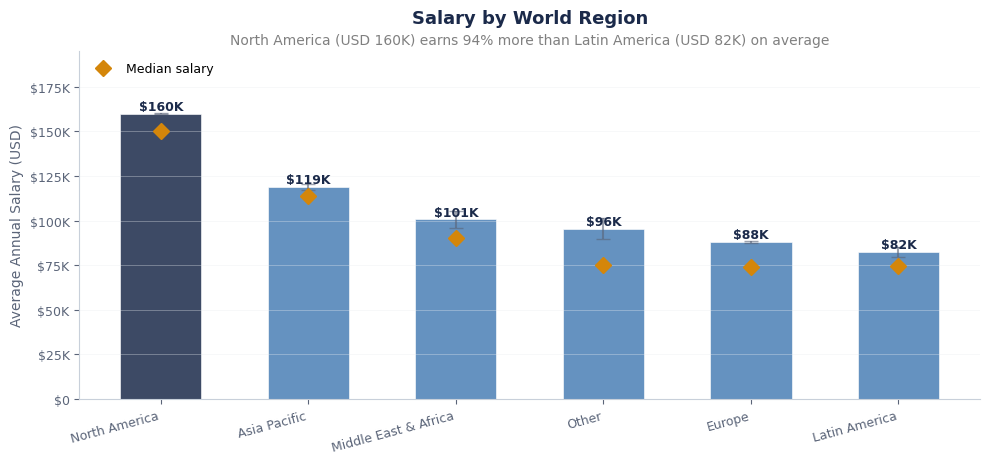

In [26]:
# Figure 11 — Regional bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Bar colors
colors_r = [NAVY if r == "North America" else STEEL for r in reg_df["region"]]
bars = ax.bar(
    reg_df["region"],
    reg_df["mean"],
    color=colors_r,
    alpha=0.85,
    width=0.55,
    edgecolor=WHITE,
    linewidth=0.5
)

# Error bars
ax.errorbar(
    reg_df["region"],
    reg_df["mean"],
    yerr=reg_df["std"] / np.sqrt(reg_df["count"]),
    fmt="none",
    color=GRAY,
    capsize=5,
    lw=1.5,
    alpha=0.6
)

# Median markers
ax.plot(
    reg_df["region"],
    reg_df["median"],
    color=AMBER,
    marker="D",
    ms=8,
    lw=0,
    label="Median salary",
    zorder=5
)

# Labels on bars
for bar, val in zip(bars, reg_df["mean"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        fmt_k(val),
        ha="center",
        fontsize=9,
        color=NAVY,
        fontweight="bold"
    )

# Axes labels
ax.set_ylabel("Average Annual Salary (USD)")

# FIXED TITLE
ax.set_title(
    "Salary by World Region",
    pad=20  # 👈 lifts title above subtitle
)

# Subtitle
add_subtitle(
    ax,
    "North America (USD 160K) earns 94% more than Latin America (USD 82K) on average"
)

# Legend — move to upper left to avoid overlapping bars
ax.legend(loc="upper left")

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, reg_df["mean"].max() * 1.22)
ax.grid(axis="y", alpha=0.4)
plt.xticks(rotation=15, ha="right")

# Layout with top margin reserved
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("11_salary_by_region")
plt.show()

---
## Section 11 — Company Size vs Salary  (Bonus Dual Axis)

**Objective:** Show whether company size correlates with compensation.

In [27]:
sz_df = (df.groupby("size_label")["salary_in_usd"]
         .agg(count="count", mean="mean", median="median")
         .round(0).reindex(["Small","Medium","Large"]).reset_index())
print("Salary by Company Size:")
print(sz_df.to_string(index=False))
lrg = sz_df[sz_df.size_label=="Large"]["mean"].values[0]
sml = sz_df[sz_df.size_label=="Small"]["mean"].values[0]
print(f"\nLarge vs Small premium: {fmt_k(lrg-sml)} (+{(lrg/sml-1)*100:.0f}%)")


Salary by Company Size:
size_label  count     mean   median
     Small    110 103530.0  95378.0
    Medium 143578 156061.0 147000.0
     Large   3660 164708.0 150400.0

Large vs Small premium: $61K (+59%)


  Saved: 12_company_size_dual_axis.png


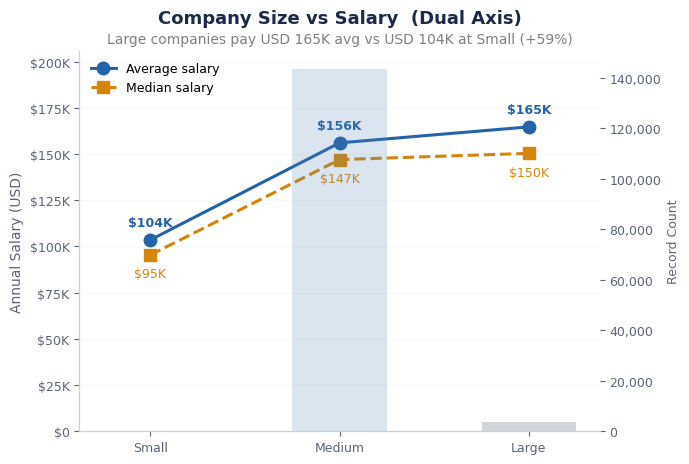

In [28]:
# Figure 12 — Company size dual axis
fig, ax = plt.subplots(figsize=(7, 5))
ax2 = ax.twinx()

# Bar colors for sizes
bar_c = [TEAL, STEEL, NAVY]
ax2.bar(
    sz_df["size_label"],
    sz_df["count"],
    color=bar_c,
    alpha=0.2,
    width=0.5,
    label="Record count"
)

# Mean and median lines
ax.plot(
    sz_df["size_label"],
    sz_df["mean"],
    color=BLUE,
    marker="o",
    lw=2.2,
    ms=9,
    label="Average salary",
    zorder=5
)
ax.plot(
    sz_df["size_label"],
    sz_df["median"],
    color=AMBER,
    marker="s",
    lw=2.2,
    ms=9,
    ls="--",
    label="Median salary",
    zorder=5
)

# Annotations for mean & median
for x_pos, avg, med in zip(sz_df["size_label"], sz_df["mean"], sz_df["median"]):
    ax.annotate(
        fmt_k(avg),
        xy=(x_pos, avg),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=BLUE,
        fontweight="bold"
    )
    ax.annotate(
        fmt_k(med),
        xy=(x_pos, med),
        xytext=(0, -16),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=AMBER
    )

# Axes labels
ax.set_ylabel("Annual Salary (USD)")
ax2.set_ylabel("Record Count", color=GRAY, fontsize=9)
ax2.tick_params(axis="y", colors=GRAY)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# FIXED TITLE
ax.set_title(
    "Company Size vs Salary  (Dual Axis)",
    pad=20  # 👈 lifts title above subtitle
)

# Subtitle
add_subtitle(
    ax,
    "Large companies pay USD 165K avg vs USD 104K at Small (+59%)"
)

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, sz_df["mean"].max() * 1.25)
lines1, labels1 = ax.get_legend_handles_labels()

# Legend — move upper left to avoid overlap
ax.legend(lines1, labels1, loc="upper left")

# Grid
ax.grid(axis="y", alpha=0.4)

# Layout with top margin reserved
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("12_company_size_dual_axis")
plt.show()

---
## Section 12 — AI/ML Core vs Data & Tech  (Bonus)

**Objective:** Quantify the salary premium for strictly AI/ML roles vs broader data/tech roles.

In [29]:
core_df = (df.groupby(["is_ai_core","exp_label"])["salary_in_usd"]
           .mean().unstack().reindex(columns=EXP_ORDER).round(0))
print("Avg Salary — AI/ML Core vs Data & Tech by Experience:")
print(core_df.to_string())
overall = df.groupby("is_ai_core")["salary_in_usd"].agg(["mean","count","median"]).round(0)
print("\nOverall:")
print(overall.to_string())
prem = (overall.loc["AI / ML Core","mean"] / overall.loc["Data & Tech","mean"] - 1) * 100
diff = overall.loc["AI / ML Core","mean"] - overall.loc["Data & Tech","mean"]
print(f"\nAI/ML Core premium over Data & Tech: +{prem:.1f}% (+{fmt_k(diff)})")

core_summary = overall.reset_index()
core_summary.to_csv(f"{OUT_DIR}/summary_ai_core_vs_tech.csv", index=False)
print("Saved: summary_ai_core_vs_tech.csv")


Avg Salary — AI/ML Core vs Data & Tech by Experience:
exp_label     Entry Level  Mid Level    Senior  Executive
is_ai_core                                               
AI / ML Core     134148.0   152108.0  182220.0   195427.0
Data & Tech       97056.0   135998.0  165316.0   196010.0

Overall:
                  mean   count    median
is_ai_core                              
AI / ML Core  171009.0   40252  161000.0
Data & Tech   150685.0  107096  140700.0

AI/ML Core premium over Data & Tech: +13.5% (+$20K)
Saved: summary_ai_core_vs_tech.csv


  Saved: 13_ai_core_vs_data_tech.png


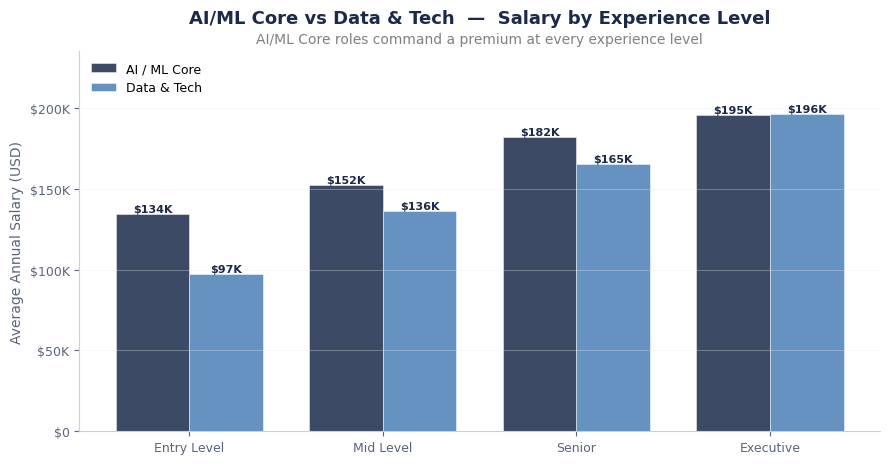

In [30]:
# Figure 13 — AI Core vs Data Tech grouped bar
x = np.arange(len(EXP_ORDER))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))

# Plot grouped bars
for i, (label, color) in enumerate([("AI / ML Core", NAVY), ("Data & Tech", STEEL)]):
    if label in core_df.index:
        vals = core_df.loc[label].values
        bars = ax.bar(
            x + i*w - w/2,
            vals,
            width=w,
            color=color,
            alpha=0.85,
            label=label,
            edgecolor=WHITE,
            linewidth=0.4
        )
        # Annotate bars
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1200,
                fmt_k(val),
                ha="center",
                fontsize=8,
                color=NAVY,
                fontweight="bold"
            )

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel("Average Annual Salary (USD)")

# FIXED TITLE
ax.set_title(
    "AI/ML Core vs Data & Tech  —  Salary by Experience Level",
    pad=20  # 👈 lifts title above subtitle
)

# Subtitle
add_subtitle(
    ax,
    "AI/ML Core roles command a premium at every experience level"
)

# Legend — move upper left to avoid overlapping tallest bars
ax.legend(loc="upper left")

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, core_df.values.max() * 1.2)
ax.grid(axis="y", alpha=0.4)

# Layout with top margin reserved
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("13_ai_core_vs_data_tech")
plt.show()

---
## Section 13 — US vs Rest of World  (Bonus)

**Objective:** Quantify the US salary premium across experience levels.

In [31]:
us_df = (df.groupby(["is_us","exp_label"])["salary_in_usd"]
         .mean().unstack().reindex(columns=EXP_ORDER).round(0))
print("Avg Salary — US vs Rest of World by Experience:")
print(us_df.to_string())
overall_us = df.groupby("is_us")["salary_in_usd"].agg(["mean","count","median"]).round(0)
print("\nOverall:")
print(overall_us.to_string())
prem = (overall_us.loc["United States","mean"] / overall_us.loc["Rest of World","mean"] - 1) * 100
print(f"\nUS premium over Rest of World: +{prem:.1f}%")

overall_us.reset_index().to_csv(f"{OUT_DIR}/summary_us_vs_row.csv", index=False)
print("Saved: summary_us_vs_row.csv")


Avg Salary — US vs Rest of World by Experience:
exp_label      Entry Level  Mid Level    Senior  Executive
is_us                                                     
Rest of World      74661.0    97898.0  121656.0   163682.0
United States     107709.0   145712.0  174687.0   198573.0

Overall:
                   mean   count    median
is_us                                    
Rest of World  108024.0   14205   94936.0
United States  161381.0  133143  150400.0

US premium over Rest of World: +49.4%
Saved: summary_us_vs_row.csv


  Saved: 14_us_vs_row.png


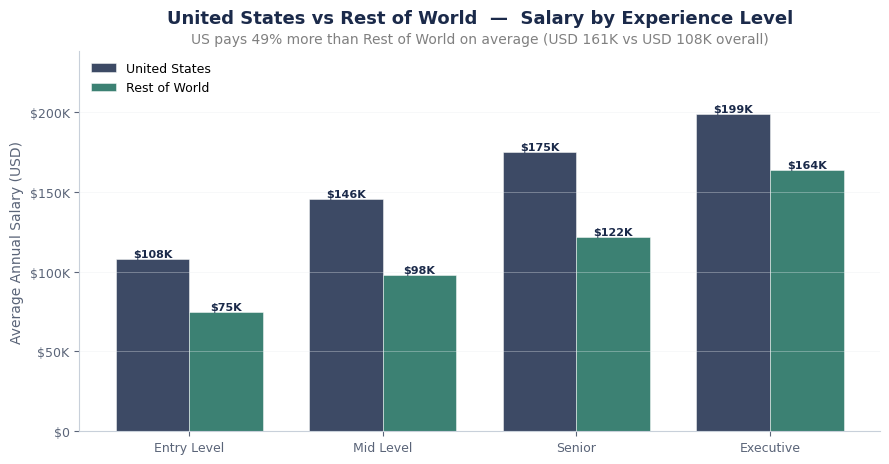

In [32]:
# Figure 14 — US vs Rest of World grouped bar
x = np.arange(len(EXP_ORDER))
w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))

# Plot grouped bars
for i, (label, color) in enumerate([("United States", NAVY), ("Rest of World", TEAL)]):
    if label in us_df.index:
        vals = us_df.loc[label].values
        bars = ax.bar(
            x + i*w - w/2,
            vals,
            width=w,
            color=color,
            alpha=0.85,
            label=label,
            edgecolor=WHITE,
            linewidth=0.4
        )
        # Annotate bars
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1200,
                fmt_k(val),
                ha="center",
                fontsize=8,
                color=NAVY,
                fontweight="bold"
            )

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(EXP_ORDER)
ax.set_ylabel("Average Annual Salary (USD)")

# FIXED TITLE
ax.set_title(
    "United States vs Rest of World  —  Salary by Experience Level",
    pad=20  # 👈 lifts title above subtitle
)

# Subtitle
add_subtitle(
    ax,
    "US pays 49% more than Rest of World on average (USD 161K vs USD 108K overall)"
)

# Legend — move upper left to avoid overlapping tallest bars
ax.legend(loc="upper left")

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_ylim(0, us_df.values.max() * 1.2)
ax.grid(axis="y", alpha=0.4)

# Layout with top margin reserved
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save & show
save_fig("14_us_vs_row")
plt.show()

---
## Section 14 — Heatmaps  (Bonus)

**Objective:** Show salary patterns across two dimensions simultaneously.

In [33]:
ROLES_SORTED = (df.groupby("title_group")["salary_in_usd"]
                .mean().sort_values(ascending=False).index.tolist())

# Role x Year heatmap data
hm = (df.groupby(["title_group","work_year"])["salary_in_usd"]
      .mean().unstack().round(0).reindex(ROLES_SORTED))
print("Role x Year Avg Salary Heatmap (in USD):")
print(hm.to_string())


Role x Year Avg Salary Heatmap (in USD):
work_year                  2022      2023      2024      2025
title_group                                                  
ML Engineer / MLOps    155345.0  191034.0  196139.0  194347.0
Software Engineer      150000.0   62724.0  181979.0  178497.0
Research Scientist     146203.0  184215.0  179955.0  168535.0
Product Manager             NaN  138553.0  175278.0  174010.0
Manager / Director     128621.0  135665.0  164951.0  182442.0
Data Architect         163369.0  157464.0  168522.0  173824.0
AI / ML Researcher     130046.0  174517.0  167620.0  167427.0
Data Scientist         147143.0  167922.0  160648.0  157759.0
Other Tech             142048.0  145662.0  152358.0  151516.0
Other                   40000.0   97500.0  140203.0  159943.0
Data Engineer          141350.0  149577.0  149309.0  146396.0
Analytics Engineer     139696.0  147251.0  134565.0  134976.0
Consultant / Analyst   116500.0  109576.0  123947.0  126149.0
Data Governance & Ops  100422

  Saved: 15_heatmap_role_year.png


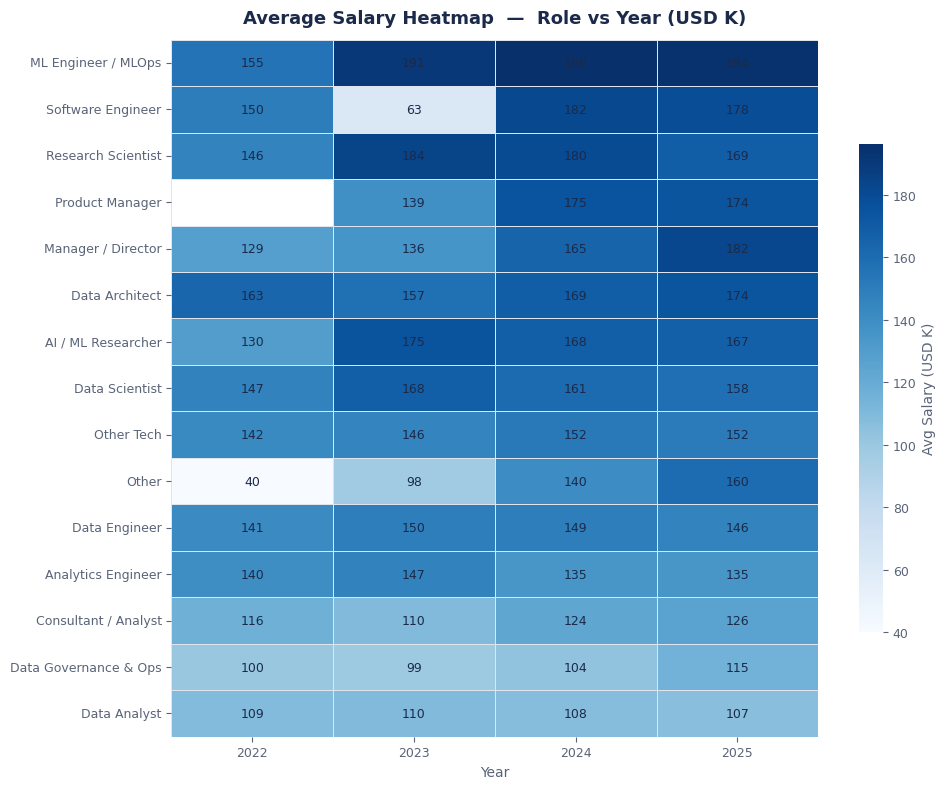

In [34]:
# Figure 15 — Role x Year heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(hm/1000, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, linecolor="#E0E4EC",
            cbar_kws={"label":"Avg Salary (USD K)","shrink":0.7},
            ax=ax, annot_kws={"size":9, "color":NAVY})
ax.set_title("Average Salary Heatmap  —  Role vs Year (USD K)")
ax.set_xlabel("Year")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
save_fig("15_heatmap_role_year")
plt.show()


  Saved: 16_remote_by_role_heatmap.png


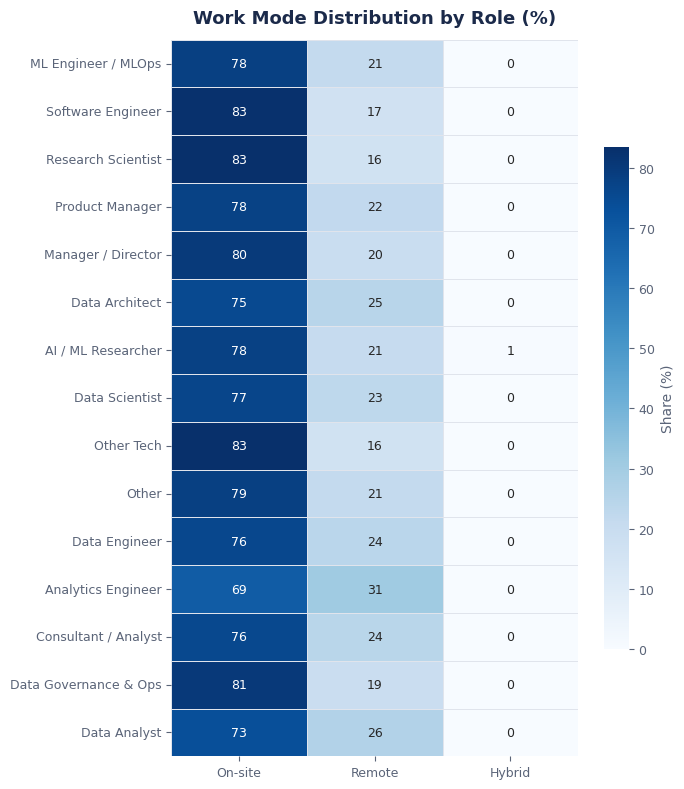

In [35]:
# Figure 16 — Work mode by role heatmap
rr_hm = (df.groupby(["title_group","work_mode"]).size()
         .unstack(fill_value=0).reindex(ROLES_SORTED))
for col in ["On-site","Remote","Hybrid"]:
    if col not in rr_hm.columns: rr_hm[col] = 0
rr_pct = (rr_hm[["On-site","Remote","Hybrid"]]
          .div(rr_hm.sum(axis=1), axis=0) * 100)

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(rr_pct, annot=True, fmt=".0f", cmap="Blues",
            linewidths=0.5, linecolor="#E0E4EC",
            cbar_kws={"label":"Share (%)","shrink":0.7},
            ax=ax, annot_kws={"size":9})
ax.set_title("Work Mode Distribution by Role (%)")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
save_fig("16_remote_by_role_heatmap")
plt.show()


---
## Section 15 — Salary Quartile by Role  (Bonus)

**Objective:** Show which roles have the most top-quartile earners.

In [36]:
QUART_ORDER = ["Q1 — Bottom 25%","Q2 — 25-50%","Q3 — 50-75%","Q4 — Top 25%"]
# Normalize quartile column to match
df["salary_quartile_clean"] = df["salary_quartile"].str.replace("—","—")
qt = (df.groupby(["title_group","salary_quartile_clean"]).size()
      .unstack(fill_value=0))
# match available columns
avail_q = [q for q in QUART_ORDER if q in qt.columns]
if not avail_q:
    avail_q = sorted(qt.columns.tolist())
qt_pct = qt[avail_q].div(qt[avail_q].sum(axis=1), axis=0) * 100
qt_pct = qt_pct.reindex(ROLES_SORTED)
print("Quartile share per role (%):")
print(qt_pct.round(1).to_string())


Quartile share per role (%):
salary_quartile_clean  Q1 — Bottom 25%  Q4 — Top 25%
title_group                                         
ML Engineer / MLOps               14.0          86.0
Software Engineer                 25.3          74.7
Research Scientist                29.5          70.5
Product Manager                   28.9          71.1
Manager / Director                38.2          61.8
Data Architect                    32.3          67.7
AI / ML Researcher                39.4          60.6
Data Scientist                    42.2          57.8
Other Tech                        54.9          45.1
Other                             57.0          43.0
Data Engineer                     58.2          41.8
Analytics Engineer                71.8          28.2
Consultant / Analyst              81.2          18.8
Data Governance & Ops             87.9          12.1
Data Analyst                      94.0           6.0


  Saved: 17_quartile_by_role.png


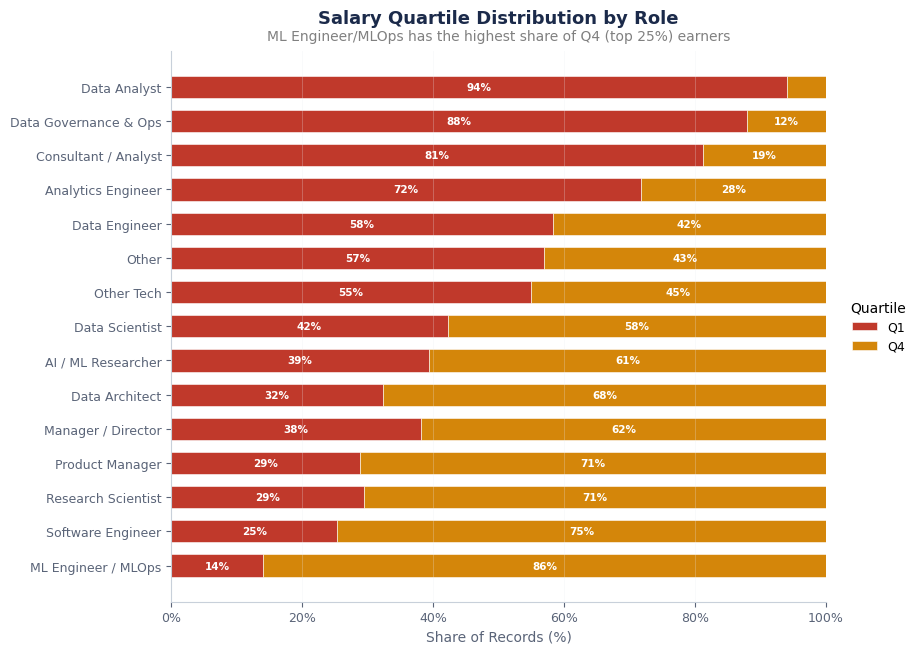

In [37]:
# Figure 17 — Stacked 100% bar: quartile by role
q_colors = [CORAL, AMBER, STEEL, NAVY]
fig, ax = plt.subplots(figsize=(11, 7))

bottoms = np.zeros(len(ROLES_SORTED))

for col, color in zip(avail_q, q_colors):
    vals = qt_pct[col].values
    ax.barh(
        ROLES_SORTED,
        vals,
        left=bottoms,
        color=color,
        label=col.split(" — ")[0].strip() if " — " in col else col,
        height=0.65,
        edgecolor=WHITE,
        linewidth=0.4
    )
    # Annotate values
    for i, (val, bot) in enumerate(zip(vals, bottoms)):
        if val > 8:
            ax.text(
                bot + val/2,
                i,
                f"{val:.0f}%",
                ha="center",
                va="center",
                fontsize=7.5,
                color=WHITE,
                fontweight="bold"
            )
    bottoms += vals

# Axes
ax.set_xlim(0, 100)
ax.set_xlabel("Share of Records (%)")

# FIXED TITLE
ax.set_title(
    "Salary Quartile Distribution by Role",
    pad=20  # lifts title above subtitle
)

# Subtitle
add_subtitle(
    ax,
    "ML Engineer/MLOps has the highest share of Q4 (top 25%) earners"
)

# Legend — move completely outside the axes
ax.legend(
    title="Quartile",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # outside right, vertically centered
    fontsize=9,
    title_fontsize=10
)

# Formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.grid(axis="x", alpha=0.3)

# Layout with top margin reserved and space for legend
plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # shrink axes width to leave room for legend

# Save & show
save_fig("17_quartile_by_role")
plt.show()

---
## Section 16 — Salary Deviation Benchmarks  (Bonus)

**Objective:** Show how individual salaries compare to their year and role averages.

In [38]:
print("Salary vs Year Average (pct):")
print(df["salary_vs_year_avg_pct"].describe().round(1))
print(f"\n{(df['salary_vs_year_avg_pct'] > 0).mean()*100:.1f}% of records are above their year average")
print(f"{(df['salary_vs_year_avg_pct'] > 50).mean()*100:.1f}% earn more than 50% above their year average")
print()
print("Salary vs Role Average (pct):")
print(df["salary_vs_role_avg_pct"].describe().round(1))


Salary vs Year Average (pct):
count    147348.0
mean         -0.0
std          42.2
min         -76.0
25%         -31.1
50%          -5.9
75%          26.2
max         175.0
Name: salary_vs_year_avg_pct, dtype: float64

44.8% of records are above their year average
13.1% earn more than 50% above their year average

Salary vs Role Average (pct):
count    147348.0
mean         -0.0
std          39.6
min         -80.3
25%         -29.1
50%          -5.5
75%          24.0
max         258.3
Name: salary_vs_role_avg_pct, dtype: float64


  Saved: 18_salary_vs_year_avg_scatter.png


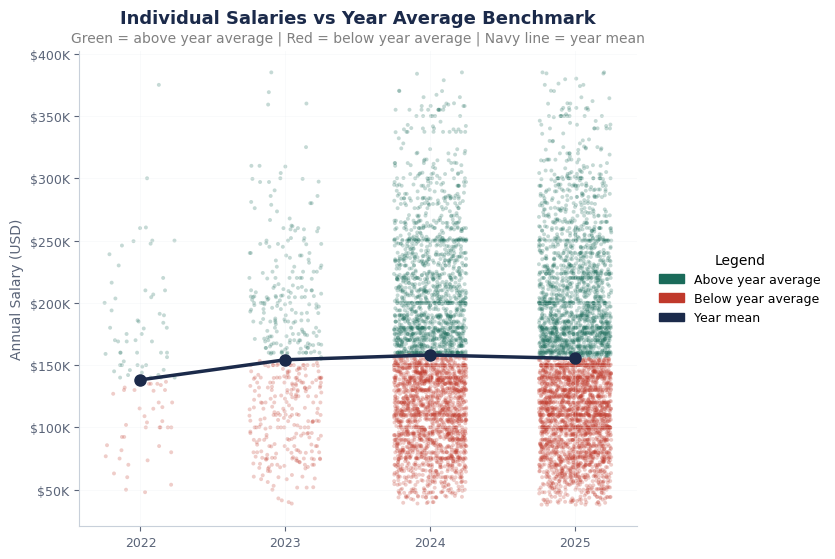

In [39]:
# Figure 18 — Scatter: individual salary vs year average
samp = df.sample(min(8000, len(df)), random_state=42)
colors_s = [TEAL if v > 0 else CORAL for v in samp["salary_vs_year_avg_pct"]]

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter points with slight jitter
ax.scatter(
    samp["work_year"] + np.random.uniform(-0.25, 0.25, len(samp)),
    samp["salary_in_usd"],
    c=colors_s,
    alpha=0.25,
    s=8,
    linewidths=0
)

# Year average line
yr_avg = df.groupby("work_year")["salary_in_usd"].mean()
ax.plot(
    YEARS,
    [yr_avg[y] for y in YEARS],
    color=NAVY,
    lw=2.5,
    marker="o",
    ms=8,
    zorder=10,
    label="Year average"
)

# Axes labels and ticks
ax.set_ylabel("Annual Salary (USD)")
ax.set_xticks(YEARS)

# Title & subtitle
ax.set_title("Individual Salaries vs Year Average Benchmark", pad=20)
add_subtitle(
    ax,
    "Green = above year average | Red = below year average | Navy line = year mean"
)

# Y-axis formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.grid(alpha=0.3)

# Legend — moved outside to the right
above_p = mpatches.Patch(color=TEAL,  label="Above year average")
below_p = mpatches.Patch(color=CORAL, label="Below year average")
avg_l   = mpatches.Patch(color=NAVY,  label="Year mean")

ax.legend(
    handles=[above_p, below_p, avg_l],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # outside right, vertically centered
    fontsize=9,
    title="Legend",
    title_fontsize=10
)

# Layout with space for legend
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# Save & show
save_fig("18_salary_vs_year_avg_scatter")
plt.show()

  Saved: 19_year_experience_lines.png


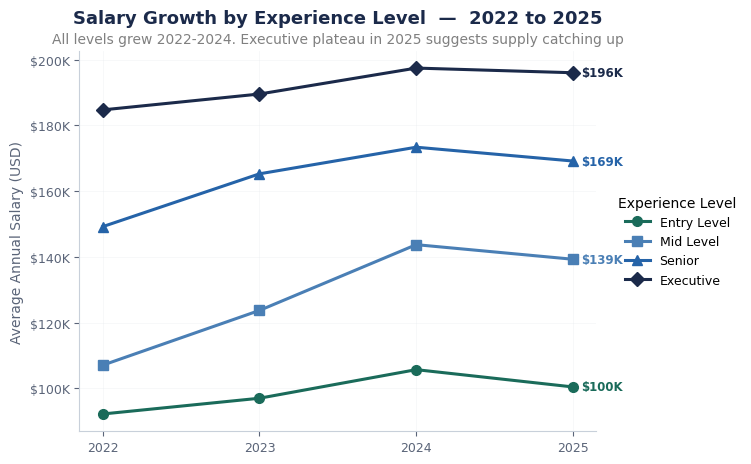

In [40]:
# Figure 19 — Role salary trend by year (line chart)
YEAR_PAL = {2022:"#4A7FB5", 2023:"#2563A8", 2024:"#1B2A4A", 2025:TEAL}

# Pivot by work_year and experience label
ye_df = (df.groupby(["work_year","exp_label"])["salary_in_usd"]
         .mean().unstack().reindex(columns=EXP_ORDER).round(0))

# Markers for experience levels
markers = {"Entry Level":"o","Mid Level":"s","Senior":"^","Executive":"D"}

fig, ax = plt.subplots(figsize=(9, 5))

# Plot lines
for exp in EXP_ORDER:
    ax.plot(
        YEARS,
        ye_df[exp],
        color=EXP_PALETTE[exp],
        marker=markers[exp],
        lw=2.2,
        ms=7,
        label=exp
    )
    # Annotate the last point (2025)
    ax.annotate(
        fmt_k(ye_df[exp].iloc[-1]),
        xy=(YEARS[-1], ye_df[exp].iloc[-1]),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=8.5,
        color=EXP_PALETTE[exp],
        fontweight="bold"
    )

# Axes labels and ticks
ax.set_ylabel("Average Annual Salary (USD)")
ax.set_xticks(YEARS)

# Title & subtitle
ax.set_title("Salary Growth by Experience Level  —  2022 to 2025", pad=20)
add_subtitle(
    ax,
    "All levels grew 2022-2024. Executive plateau in 2025 suggests supply catching up"
)

# Formatting
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.grid(alpha=0.4)

# Legend — moved outside to the right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # outside right, vertically centered
    fontsize=9,
    title="Experience Level",
    title_fontsize=10
)

# Layout with space for legend
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# Save & show
save_fig("19_year_experience_lines")
plt.show()

  Saved: 20_salary_range_by_role.png


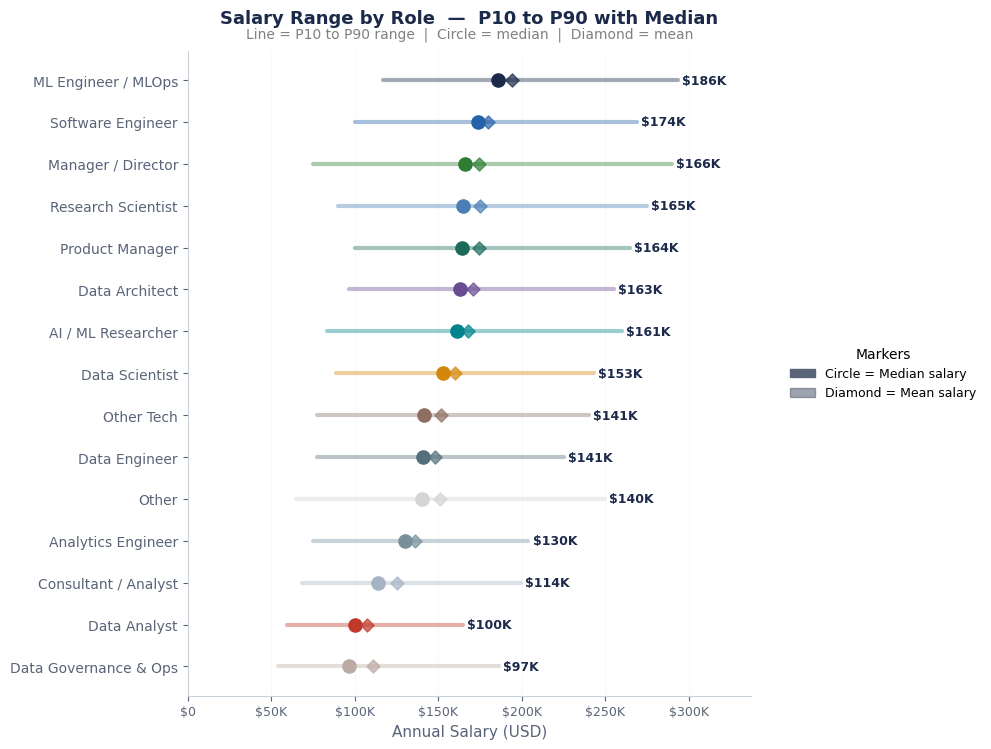

          title_group      q10   median      q90     mean  count
Data Governance & Ops  54000.0  96810.0 186430.0 110824.0   3380
         Data Analyst  59481.0 100000.0 165000.0 107465.0  14795
 Consultant / Analyst  68341.0 113686.0 199400.0 125379.0   2528
   Analytics Engineer  75000.0 130000.0 204000.0 136245.0   4089
                Other  65000.0 140000.0 250000.0 151297.0   1489
        Data Engineer  77100.0 141000.0 225000.0 147864.0  16510
           Other Tech  77120.0 141440.0 240000.0 151747.0  30373
       Data Scientist  88641.0 153000.0 243000.0 160003.0  20784
   AI / ML Researcher  83202.0 161343.0 259956.0 167597.0   3306
       Data Architect  96600.0 163000.0 255000.0 170929.0   4525
      Product Manager 100000.0 164000.0 264561.0 174293.0   3455
   Research Scientist  90000.0 165000.0 275000.0 175054.0   7089
   Manager / Director  75000.0 166232.0 290000.0 174149.0   4092
    Software Engineer 100000.0 174000.0 269088.0 180027.0  21860
  ML Engineer / MLOps 116

In [41]:
# Figure 20 — Salary spread per role (Min, Median, Max horizontal range)
role_stats = (df.groupby("title_group")["salary_in_usd"]
              .agg(q10=lambda x: x.quantile(0.10),
                   median="median",
                   q90=lambda x: x.quantile(0.90),
                   mean="mean",
                   count="count")
              .round(0)
              .sort_values("median", ascending=True)
              .reset_index())

fig, ax = plt.subplots(figsize=(12, 8))

for i, row in role_stats.iterrows():
    color = ROLE_PALETTE.get(row["title_group"], STEEL)
    # Draw range line (P10 to P90)
    ax.plot([row["q10"], row["q90"]], [i, i],
            color=color, lw=3, alpha=0.4, solid_capstyle="round")
    # Draw median marker
    ax.scatter(row["median"], i, color=color, s=90, zorder=5)
    # Draw mean marker
    ax.scatter(row["mean"], i, color=color, marker="D", s=45, zorder=5, alpha=0.7)
    # Label median — ensure it stays inside the axis
    label_x = min(row["q90"] + 2500, ax.get_xlim()[1] * 0.98)
    ax.text(label_x, i, fmt_k(row["median"]),
            va="center", ha="left", fontsize=9, color=NAVY, fontweight="bold")

# Y-axis labels
ax.set_yticks(range(len(role_stats)))
ax.set_yticklabels(role_stats["title_group"], fontsize=10)

# Labels & title
ax.set_xlabel("Annual Salary (USD)", fontsize=11)
ax.set_title("Salary Range by Role  —  P10 to P90 with Median", fontsize=13, pad=20)
add_subtitle(ax, "Line = P10 to P90 range  |  Circle = median  |  Diamond = mean")

# Formatting
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xlim(0, role_stats["q90"].max() * 1.15)  # slightly tighter to leave room
ax.grid(axis="x", alpha=0.4)

# Legend — moved fully outside right
circle_p  = mpatches.Patch(color=GRAY, label="Circle = Median salary")
diamond_p = mpatches.Patch(color=GRAY, label="Diamond = Mean salary", alpha=0.6)
ax.legend(handles=[circle_p, diamond_p],
          fontsize=9, loc="center left", bbox_to_anchor=(1.05, 0.5), title="Markers")

# Tight layout with space for legend
plt.tight_layout(rect=[0, 0, 0.85, 0.95])

# Save & show
save_fig("20_salary_range_by_role")
plt.show()

# Display table
print(role_stats[["title_group","q10","median","q90","mean","count"]].to_string(index=False))

---
## Section 17 — Actionable Insights Summary

### For Job Seekers / CS Students

| Insight | Action |
|---------|--------|
| ML Engineer/MLOps pays USD 194K avg — 81% above Data Analyst | Prioritize ML Ops skills (Docker, Kubernetes, MLflow) alongside modeling |
| Executive earns 1.91x Entry Level | Career progression within AI/ML delivers strong returns |
| Remote work has collapsed to 20% by 2025 | Plan for on-site — do not assume remote is the default |
| US pays 49% more than Rest of World | US jobs or US-paying remote roles are significantly more valuable |
| AI/ML Core roles earn +13% more than Data & Tech | Specializing in AI/ML specifically commands a real premium |

### For Organizations / HR

| Insight | Action |
|---------|--------|
| Median salary is USD 147K for FT AI/ML talent | Benchmark offers above USD 147K to be competitive |
| Salary growth plateaued in 2025 after surging 2022-2024 | 2025 is a good year to hire at stabilized rates |
| Large companies pay 59% more than Small | Small orgs need equity or flexibility to compete |
| 90% of submissions are US-based | Canada and UK are the most viable non-US talent pools |

### For Policy / Education

| Insight | Action |
|---------|--------|
| Entry Level averages USD 103K — strong immediate ROI | AI/ML education investment is clearly justified |
| Salary spread is USD 87K between lowest and top roles | Curriculum should differentiate ML engineering from data analysis tracks |


---
## Section 18 — Export Master Summary CSV

In [42]:
# Master KPI summary CSV
master = {
    "total_records":         len(df),
    "median_salary":         int(df["salary_in_usd"].median()),
    "mean_salary":           int(df["salary_in_usd"].mean()),
    "min_salary":            int(df["salary_in_usd"].min()),
    "max_salary":            int(df["salary_in_usd"].max()),
    "skewness":              round(df["salary_in_usd"].skew(), 3),
    "entry_level_avg":       int(df[df.exp_label=="Entry Level"]["salary_in_usd"].mean()),
    "mid_level_avg":         int(df[df.exp_label=="Mid Level"]["salary_in_usd"].mean()),
    "senior_avg":            int(df[df.exp_label=="Senior"]["salary_in_usd"].mean()),
    "executive_avg":         int(df[df.exp_label=="Executive"]["salary_in_usd"].mean()),
    "ex_en_ratio":           round(df[df.exp_label=="Executive"]["salary_in_usd"].mean() /
                                   df[df.exp_label=="Entry Level"]["salary_in_usd"].mean(), 3),
    "remote_pct_2022":       round((df[df.work_year==2022]["work_mode"]=="Remote").mean()*100, 1),
    "remote_pct_2025":       round((df[df.work_year==2025]["work_mode"]=="Remote").mean()*100, 1),
    "onsite_pct_2025":       round((df[df.work_year==2025]["work_mode"]=="On-site").mean()*100, 1),
    "us_share_pct":          round((df.company_location=="US").mean()*100, 1),
    "us_avg_salary":         int(df[df.company_location=="US"]["salary_in_usd"].mean()),
    "row_avg_salary":        int(df[df.is_us=="Rest of World"]["salary_in_usd"].mean()),
    "ai_core_avg":           int(df[df.is_ai_core=="AI / ML Core"]["salary_in_usd"].mean()),
    "data_tech_avg":         int(df[df.is_ai_core=="Data & Tech"]["salary_in_usd"].mean()),
    "top_role":              "ML Engineer / MLOps",
    "top_role_avg":          int(df[df.title_group=="ML Engineer / MLOps"]["salary_in_usd"].mean()),
    "salary_2022_avg":       int(df[df.work_year==2022]["salary_in_usd"].mean()),
    "salary_2024_avg":       int(df[df.work_year==2024]["salary_in_usd"].mean()),
    "salary_growth_22_24":   round((df[df.work_year==2024]["salary_in_usd"].mean() /
                                    df[df.work_year==2022]["salary_in_usd"].mean()-1)*100, 1),
    "unique_countries":      df["company_location"].nunique(),
    "unique_role_groups":    df["title_group"].nunique(),
    "years_covered":         "2022, 2023, 2024, 2025",
}
summary_df = pd.DataFrame(list(master.items()), columns=["metric","value"])
summary_df.to_csv(f"{OUT_DIR}/analysis_summary.csv", index=False)
print("Saved: analysis_summary.csv")
print()
print(summary_df.to_string(index=False))


Saved: analysis_summary.csv

             metric                  value
      total_records                 147348
      median_salary                 147000
        mean_salary                 156237
         min_salary                  37974
         max_salary                 385000
           skewness                  0.682
    entry_level_avg                 102743
      mid_level_avg                 140382
         senior_avg                 170351
      executive_avg                 195934
        ex_en_ratio                  1.907
    remote_pct_2022                   53.5
    remote_pct_2025                   20.3
    onsite_pct_2025                   79.6
       us_share_pct                   90.4
      us_avg_salary                 161380
     row_avg_salary                 108024
        ai_core_avg                 171008
      data_tech_avg                 150685
           top_role    ML Engineer / MLOps
       top_role_avg                 194302
    salary_2022_avg      

In [43]:
# Confirm all outputs
import os
print("=== OUTPUT FIGURES ===")
figs = sorted([f for f in os.listdir(FIG_DIR) if f.endswith(".png")])
for f in figs:
    size = os.path.getsize(f"{FIG_DIR}/{f}")
    print(f"  {f:<48s}  {size/1024:>6.1f} KB")

print(f"\n=== OUTPUT CSVs ===")
csvs = sorted([f for f in os.listdir(OUT_DIR) if f.endswith(".csv")])
for f in csvs:
    size = os.path.getsize(f"{OUT_DIR}/{f}")
    print(f"  {f:<40s}  {size:>7,} bytes")

print(f"\nTotal figures : {len(figs)}")
print(f"Total CSVs    : {len(csvs)}")


=== OUTPUT FIGURES ===
  01_salary_distribution.png                          57.5 KB
  02_salary_band_distribution.png                     64.9 KB
  03_salary_trend_dual_axis.png                       95.5 KB
  04_salary_by_role.png                              113.2 KB
  05_work_mode_donut.png                              50.7 KB
  06_top_countries_salary.png                         93.9 KB
  07_salary_vs_experience.png                         83.6 KB
  08_experience_boxplot.png                           59.2 KB
  09_kpi_summary_cards.png                            84.8 KB
  10_remote_trend_stacked.png                         60.2 KB
  11_salary_by_region.png                             77.6 KB
  12_company_size_dual_axis.png                       82.7 KB
  13_ai_core_vs_data_tech.png                         59.5 KB
  14_us_vs_row.png                                    66.3 KB
  15_heatmap_role_year.png                           120.7 KB
  16_remote_by_role_heatmap.png                

---
*CS3012 Data Visualization · Group 8 · FAST-NUCES Islamabad · Spring 2026*  
*Dataset: aijobs.net / foorilla.com · CC0 Public Domain*
